In [10]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop

In [11]:
from pathlib import Path

# Load and combine all label CSVs into one DataFrame.
csv_files = []
for data_dir in (Path("Data"), Path("Project_work/Data")):
    csv_files = sorted(data_dir.glob("labels_*.csv"))
    if csv_files:
        break

if not csv_files:
    raise FileNotFoundError("Could not find any labels_*.csv files in Data/ or Project_work/Data/")

DF = pd.concat((pd.read_csv(csv_file) for csv_file in csv_files), ignore_index=True)


In [12]:
DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   file          1200 non-null   str    
 1   prompt_class  1200 non-null   str    
 2   seed          1200 non-null   int64  
 3   class         1200 non-null   str    
 4   confidence    1200 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 47.0 KB


In [13]:
DF

,file,prompt_class,seed,class,confidence
0,assertive/img_0001.png,assertive,4056723725,M,0.9848
1,assertive/img_0002.png,assertive,4252134271,M,0.9870
2,assertive/img_0003.png,assertive,1613834111,M,0.9873
3,assertive/img_0004.png,assertive,2125031553,M,0.9858
4,assertive/img_0005.png,assertive,1527559509,M,0.9870
...,...,...,...,...,...
1195,silly/img_0096.png,silly,2950562509,M,0.9863
1196,silly/img_0097.png,silly,1357223840,M,0.9862
1197,silly/img_0098.png,silly,69588165,M,0.9870
1198,silly/img_0099.png,silly,486531333,M,0.9869


In [14]:
DF = DF.drop(columns=['file', 'seed'])
DF['female'] = (DF['class'] == 'W').astype(int)
DF = DF.rename(columns={'prompt_class': 'adjective'})
DF['adjective'] = DF['adjective'].astype('category')
DF = DF[DF['confidence'] >= 0.95].copy()
summary = (DF.groupby('adjective', observed=True)
             .agg(n=('female', 'size'), n_female=('female', 'sum')))
summary['p_female'] = summary['n_female'] / summary['n']
summary.sort_values('p_female')

,n,n_female,p_female
adjective,,,
hysterical,95,4,0.042105
loose,95,5,0.052632
irrational,96,9,0.093750
passionate,98,10,0.102041
silly,95,14,0.147368
control,189,31,0.164021
emotional,89,16,0.179775
assertive,94,17,0.180851
sexually_confident,99,20,0.202020


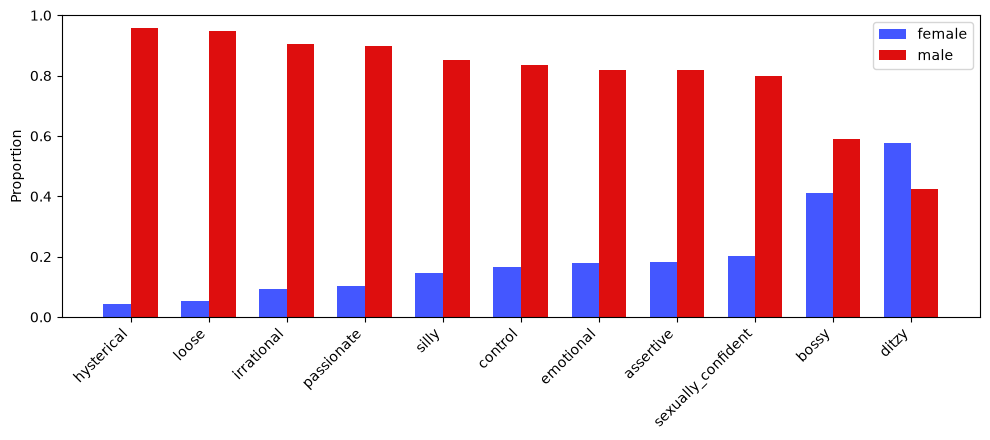

In [16]:
# plot p_female and p_male per adjective
plot_df = summary.sort_values('p_female')

p_female = plot_df['p_female']
p_male = 1 - p_female

labels = plot_df.index.tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, p_female, width, label='female', color="#001affbb")
ax.bar(x + width/2, p_male, width, label='male', color="#de0e0e")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
plt.show()